# Visual Alignment — Experiment 2 (Levering 2020)

Measures NLL alignment of VLMs on the Levering categorization task using Psych-101 human trial sequences as ground truth.

**Three input conditions per model:**
- `TEXT_ONLY` — digit-string stimulus codes, identical to LLM baseline
- `IMAGE_ONLY` — current trial stimulus replaced with rendered PNG; prior history remains as text
- `IMAGE_AND_TEXT` — image + `Object code: [stimulus]` caption alongside image

**Two category structures:**
- `NLS` (`exp1.csv`) — Non-Linearly Separable (Levering 2020 original)
- `LS` (`exp2.csv`) — Linearly Separable (shape-only rule)

### Imports & API Client

In [35]:
from openai import OpenAI

from tqdm import tqdm
import numpy as np
import re
import os
import io
import base64

from dotenv import load_dotenv
from datasets import load_dataset
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.gridspec as gridspec


In [36]:
load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
    base_url="https://litellm.ccv.brown.edu"
)


### Constants

In [37]:
# --- Quick-test flag ---
# Set True for fast iteration: 2 participants, 30 trials, first model only
QUICK_TEST = True

# --- Conditions ---
CONDITION_MAP = {
    "levering2020revisiting/exp1.csv": "NLS",
    "levering2020revisiting/exp2.csv": "LS",
}

# NLS structural categories (Z/W labels = conceptual; transcript tokens are W/N)
# Used only to derive exception items.
NLS_CATEGORIES = {
    "111": "Z",
    "122": "Z",
    "212": "Z",
    "121": "W",
    "211": "W",
    "222": "W",
}

# Exception items: stimuli that contradict the shape-only majority rule
# Shape-only rule: digit[0]=1 (square) -> Z, digit[0]=2 (triangle) -> W
# '212': shape=2 -> rule predicts W, true category = Z  -> EXCEPTION
# '121': shape=1 -> rule predicts Z, true category = W  -> EXCEPTION
EXCEPTION_ITEMS_NLS = ["212", "121"]

# --- Models ---
VLM_MODELS = ["claude-sonnet-4-5"]

# Input variants
INPUT_VARIANTS = ["TEXT_ONLY", "IMAGE_ONLY", "IMAGE_AND_TEXT"]

# --- Participant sampling ---
N_PARTICIPANTS = 5
SEED = 42

# --- Decision tokens (from Psych-101 transcripts) ---
CATEGORY_TOKENS = {"W", "N"}
RATING_TOKENS   = {str(i) for i in range(1, 10)}

# Apply QUICK_TEST overrides
if QUICK_TEST:
    N_PARTICIPANTS = 1
    VLM_MODELS     = VLM_MODELS[:1]
    print("QUICK_TEST enabled: 1 participant per condition, full transcript, first model only")


QUICK_TEST enabled: 2 participants, 30 trials, first model only


### Load Psych-101 & Sample Participants

Sample `N_PARTICIPANTS` participants per condition using `SEED` for reproducibility.

In [38]:
dataset = load_dataset("marcelbinz/Psych-101")
df = pd.DataFrame(dataset["train"])

# Sample participants per condition
rng = np.random.default_rng(SEED)
condition_participants = {}  # condition_name -> list of (participant_idx, transcript)

for exp_file, cond_name in CONDITION_MAP.items():
    exp_df = df[df["experiment"] == exp_file].reset_index(drop=True)
    n_available = len(exp_df)
    n_sample = min(N_PARTICIPANTS, n_available)
    indices = rng.choice(n_available, size=n_sample, replace=False).tolist()
    condition_participants[cond_name] = [
        (idx, exp_df["text"].iloc[idx]) for idx in indices
    ]
    print(f"{cond_name}: {n_available} available, sampled indices {indices}")


NLS: 126 available, sampled indices [11, 97]
LS: 102 available, sampled indices [44, 101]


### Stimulus Rendering

Each 3-digit code maps to a visual stimulus: `digit1`=shape, `digit2`=size, `digit3`=shading. All stimuli are pre-rendered once as base64 PNGs.

In [39]:
def render_stimulus(code, dpi=80):
    """Render a 3-digit stimulus code as a base64-encoded PNG image.

    digit 1 — shape  (1 = square, 2 = equilateral triangle)
    digit 2 — size   (1 = large 0.55 unit radius, 2 = small 0.32 unit radius)
    digit 3 — shade  (1 = black fill, 2 = white fill)
    Gray background, black border, high contrast.
    """
    shape = int(code[0])
    size  = int(code[1])
    shade = int(code[2])

    fig, ax = plt.subplots(figsize=(2, 2))
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal"); ax.axis("off")
    fig.patch.set_facecolor("#c8c8c8")

    sz = 0.55 if size == 1 else 0.32
    fc = "black" if shade == 1 else "white"
    cx, cy = 0.5, 0.5

    if shape == 1:
        patch = patches.Rectangle(
            (cx - sz/2, cy - sz/2), sz, sz,
            facecolor=fc, edgecolor="black", linewidth=2
        )
    else:
        h   = sz * np.sqrt(3) / 2
        pts = np.array([[cx, cy + 2*h/3],
                        [cx - sz/2, cy - h/3],
                        [cx + sz/2, cy - h/3]])
        patch = patches.Polygon(pts, closed=True,
                                facecolor=fc, edgecolor="black", linewidth=2)
    ax.add_patch(patch)

    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", pad_inches=0.05)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")


ALL_CODES = ["111", "112", "121", "122", "211", "212", "221", "222"]
STIMULUS_IMAGES = {code: render_stimulus(code) for code in ALL_CODES}
print(f"Pre-rendered {len(STIMULUS_IMAGES)} stimulus images.")


Pre-rendered 8 stimulus images.


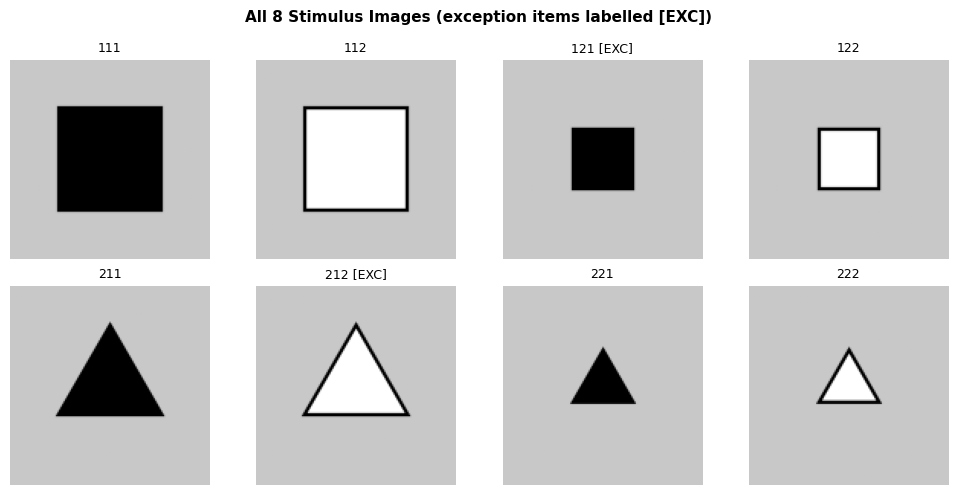

In [40]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, code in zip(axes.flat, ALL_CODES):
    img_bytes = base64.b64decode(STIMULUS_IMAGES[code])
    img = plt.imread(io.BytesIO(img_bytes), format="png")
    ax.imshow(img)
    ax.axis("off")
    exc = " [EXC]" if code in EXCEPTION_ITEMS_NLS else ""
    ax.set_title(f"{code}{exc}", fontsize=9)
fig.suptitle("All 8 Stimulus Images (exception items labelled [EXC])",
             fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("stimulus_preview_visual_alignment.png", dpi=120, bbox_inches="tight")
plt.show()


### Helper Functions

`extract_steps()` parses `<<DECISION>>` markers from Psych-101 transcripts. `parse_stimulus()` extracts the 3-digit stimulus code from a trial prefix. `compute_nll()` converts logprobs to NLL against the human decision.

In [41]:
def extract_steps(text):
    """Parse <<DECISION>> markers from a Psych-101 transcript.

    Returns a list of dicts with keys 'prefix' (context up to <<) and
    'decision' (the token inside <<...>>), skipping NaN entries.
    """
    pattern = r"<<(.*?)>>"
    matches = list(re.finditer(pattern, text))
    steps = []
    prev_end = 0
    for m in matches:
        start, end = m.span()
        decision = m.group(1).strip()
        prefix = text[prev_end:start]
        if decision.lower() == "nan":
            prev_end = end
            continue
        steps.append({"prefix": prefix, "decision": decision})
        prev_end = end
    return steps


def parse_stimulus(prefix):
    """Extract the 3-digit stimulus code from a trial prefix string.

    Looks for 'You see the image XXX' pattern. Returns None if not found.
    """
    m = re.search(r"You see the image (\d{3})", prefix)
    return m.group(1) if m else None


def compute_nll(logprobs, human_decision, valid_tokens):
    """Compute NLL of human_decision given model's top logprobs.

    Filters to valid_tokens, renormalizes probabilities, returns
    -log(p_human). Returns np.nan if human token not in top logprobs.
    """
    valid_entries = {
        entry.token.strip().upper(): entry.logprob
        for entry in logprobs
        if entry.token.strip().upper() in valid_tokens
    }
    if human_decision not in valid_entries:
        return np.nan
    log_p = np.array(list(valid_entries.values()))
    probs = np.exp(log_p)
    probs /= probs.sum()
    human_idx = list(valid_entries.keys()).index(human_decision)
    return -np.log(probs[human_idx])


def fallback_nll(top_token, human_decision):
    """NLL when logprobs unavailable: 0 if correct (p=1.0), inf if wrong."""
    return 0.0 if top_token == human_decision else np.inf


### Alignment Loop

Runs each VLM on all participants × conditions × input variants. For `IMAGE_ONLY` and `IMAGE_AND_TEXT`, the prior trial history is sent as text and only the *current* trial's stimulus is replaced by / augmented with an image.

In [42]:
def run_one_participant(model, steps, cond_name, input_variant, quick_test=False):
    """Replay one participant's trial sequence for a given model and input variant.

    Parameters
    ----------
    model        : model name string
    steps        : output of extract_steps()
    cond_name    : 'NLS' or 'LS'
    input_variant: 'TEXT_ONLY', 'IMAGE_ONLY', or 'IMAGE_AND_TEXT'
    quick_test   : unused (retained for compatibility; full transcript always runs)

    Returns a list of trial result dicts.
    """
    model_context = ""
    trial_results = []
    logprobs_supported = True  # per-participant/model flag
    n_cat_trials = 0

    for step in steps:
        human_decision = step["decision"]
        prefix         = step["prefix"]

        # Skip rating trials — just accumulate into context
        if human_decision in RATING_TOKENS:
            model_context += prefix + f"<<{human_decision}>>"
            continue

        stimulus = parse_stimulus(prefix)

        # ---- Build the API call ----
        logprobs = None
        top_token = None
        logprobs_fallback = False

        if input_variant == "TEXT_ONLY":
            prompt = model_context + prefix + "<<(Respond with only W or N)"
            messages = [{"role": "user", "content": prompt}]

        elif input_variant in ("IMAGE_ONLY", "IMAGE_AND_TEXT") and stimulus and stimulus in STIMULUS_IMAGES:
            # Split prefix into before/after the stimulus code
            m = re.search(re.escape(stimulus), prefix)
            if m:
                before = model_context + prefix[:m.start()]
                after  = prefix[m.end():] + "<<(Respond with only W or N)"
            else:
                before = model_context + prefix
                after  = "<<(Respond with only W or N)"

            img_b64 = STIMULUS_IMAGES[stimulus]
            content = [{"type": "text", "text": before}]
            content.append({"type": "image_url",
                            "image_url": {"url": f"data:image/png;base64,{img_b64}"}})
            if input_variant == "IMAGE_AND_TEXT":
                content.append({"type": "text",
                                "text": f"Object code: {stimulus}\n" + after})
            else:
                content.append({"type": "text", "text": after})
            messages = [{"role": "user", "content": content}]

        else:
            # Fallback to TEXT_ONLY if stimulus not parseable
            prompt = model_context + prefix + "<<(Respond with only W or N)"
            messages = [{"role": "user", "content": prompt}]

        # ---- Query model ----
        if logprobs_supported:
            try:
                response = client.chat.completions.create(
                    model=model,
                    messages=messages,
                    top_logprobs=5,
                    logprobs=True,
                )
                logprobs  = response.choices[0].logprobs.content[0].top_logprobs
                top_token = logprobs[0].token.strip().upper()
            except Exception as e:
                err = str(e).lower()
                if any(x in err for x in ["400", "logprob", "not supported", "unsupported"]):
                    print(f"  [{model}] logprobs not supported — falling back to top-1")
                    logprobs_supported = False
                else:
                    print(f"  [skipped trial] {e}")
                    model_context += prefix + f"<<{human_decision}>>"
                    n_cat_trials += 1
                    continue

        if not logprobs_supported:
            logprobs_fallback = True
            try:
                response = client.chat.completions.create(
                    model=model,
                    messages=messages,
                )
                raw = response.choices[0].message.content.strip().upper()
                top_token = next((t for t in CATEGORY_TOKENS if t in raw), None)
                if top_token is None:
                    print(f"  [skipped trial] unexpected response: {raw!r}")
                    model_context += prefix + f"<<{human_decision}>>"
                    n_cat_trials += 1
                    continue
            except Exception as e:
                print(f"  [skipped trial] {e}")
                model_context += prefix + f"<<{human_decision}>>"
                n_cat_trials += 1
                continue

        # ---- Record result ----
        nll = (fallback_nll(top_token, human_decision)
               if logprobs_fallback or logprobs is None
               else compute_nll(logprobs, human_decision, CATEGORY_TOKENS))

        is_exception = None
        if cond_name == "NLS" and stimulus is not None:
            is_exception = stimulus in EXCEPTION_ITEMS_NLS

        trial_results.append({
            "human_decision":   human_decision,
            "top_token":        top_token,
            "correct":          top_token == human_decision,
            "nll":              nll,
            "logprobs":         logprobs,
            "logprobs_fallback": logprobs_fallback,
            "is_exception":     is_exception,
            "stimulus":         stimulus,
        })
        model_context += prefix + f"<<{human_decision}>>"
        n_cat_trials  += 1

    return trial_results


In [43]:
# all_results[cond_name][model][input_variant] = list of trial-result dicts
# (one per participant, concatenated)
all_results = {cond: {m: {v: [] for v in INPUT_VARIANTS} for m in VLM_MODELS}
               for cond in CONDITION_MAP.values()}

for exp_file, cond_name in CONDITION_MAP.items():
    participants = condition_participants[cond_name]
    print(f"\n{'='*60}")
    print(f"CONDITION: {cond_name}  ({len(participants)} participants)")
    print(f"{'='*60}")

    for part_idx, transcript in participants:
        steps = extract_steps(transcript)
        print(f"  Participant {part_idx}: {len(steps)} total steps")

        for model in VLM_MODELS:
            for variant in INPUT_VARIANTS:
                print(f"    [{model}] [{variant}] ...", end=" ", flush=True)
                trials = run_one_participant(
                    model, steps, cond_name, variant,
                    quick_test=QUICK_TEST
                )
                all_results[cond_name][model][variant].extend(
                    [{**t, "participant_idx": part_idx} for t in trials]
                )
                n = len(trials)
                fallback = any(t["logprobs_fallback"] for t in trials)
                acc = np.mean([t["correct"] for t in trials]) if trials else float("nan")
                nll_vals = [t["nll"] for t in trials if not np.isinf(t["nll"])]
                nll_str = f"{np.nanmean(nll_vals):.3f}" if nll_vals else "N/A"
                print(f"{n} trials | acc={acc:.1%} | nll={nll_str}"
                      + (" [FALLBACK]" if fallback else ""))



CONDITION: NLS  (2 participants)
  Participant 11: 166 total steps
    [claude-sonnet-4-5] [TEXT_ONLY] ...   [claude-sonnet-4-5] logprobs not supported — falling back to top-1
  [skipped trial] Error code: 400 - {'error': {'message': 'Budget has been exceeded! Current cost: 100.25874024999993, Max budget: 100.0', 'type': 'budget_exceeded', 'param': None, 'code': '400'}}
  [skipped trial] Error code: 400 - {'error': {'message': 'Budget has been exceeded! Current cost: 100.25874024999993, Max budget: 100.0', 'type': 'budget_exceeded', 'param': None, 'code': '400'}}
  [skipped trial] Error code: 400 - {'error': {'message': 'Budget has been exceeded! Current cost: 100.25874024999993, Max budget: 100.0', 'type': 'budget_exceeded', 'param': None, 'code': '400'}}
  [skipped trial] Error code: 400 - {'error': {'message': 'Budget has been exceeded! Current cost: 100.25874024999993, Max budget: 100.0', 'type': 'budget_exceeded', 'param': None, 'code': '400'}}
  [skipped trial] Error code: 400 -

### Compute Aggregated Metrics

In [44]:
def aggregate(trials, subset=None):
    """Return mean_nll, se_nll, mean_acc for a list of trial dicts.

    subset: None = all trials, 'exception' = exception items, 'non_exception' = rest.
    Inf NLL values (logprobs fallback + wrong answer) are excluded from NLL mean
    but counted as mismatches for accuracy.
    """
    if subset == "exception":
        trials = [t for t in trials if t["is_exception"] is True]
    elif subset == "non_exception":
        trials = [t for t in trials if t["is_exception"] is False]
    if not trials:
        return {"mean_nll": np.nan, "se_nll": np.nan, "mean_acc": np.nan, "n": 0}
    nlls = np.array([t["nll"] for t in trials], dtype=float)
    finite_nlls = nlls[np.isfinite(nlls)]
    mean_nll = np.nanmean(finite_nlls) if len(finite_nlls) else np.nan
    se_nll   = (np.nanstd(finite_nlls, ddof=1) / np.sqrt(len(finite_nlls))
                if len(finite_nlls) > 1 else np.nan)
    mean_acc = np.mean([t["correct"] for t in trials])
    return {"mean_nll": mean_nll, "se_nll": se_nll, "mean_acc": mean_acc, "n": len(trials)}


metrics = {}  # metrics[cond][model][variant] = aggregate dict (+ exception breakdown for NLS)

for cond_name in CONDITION_MAP.values():
    metrics[cond_name] = {}
    for model in VLM_MODELS:
        metrics[cond_name][model] = {}
        for variant in INPUT_VARIANTS:
            trials = all_results[cond_name][model][variant]
            m = aggregate(trials)
            if cond_name == "NLS":
                m["exception"]     = aggregate(trials, subset="exception")
                m["non_exception"]  = aggregate(trials, subset="non_exception")
            metrics[cond_name][model][variant] = m

# Print summary table
for cond_name in CONDITION_MAP.values():
    print(f"\n=== {cond_name} ===")
    for model in VLM_MODELS:
        for variant in INPUT_VARIANTS:
            m = metrics[cond_name][model][variant]
            row = (f"  {model.split('-')[0]:<10} {variant:<18} "
                   f"NLL={m['mean_nll']:.3f} (SE={m['se_nll']:.3f}) "
                   f"Acc={m['mean_acc']:.1%} n={m['n']}")
            if cond_name == "NLS" and "exception" in m:
                exc = m["exception"]
                non = m["non_exception"]
                row += (f" | exc_nll={exc['mean_nll']:.3f} non_exc_nll={non['mean_nll']:.3f}")
            print(row)



=== NLS ===
  claude     TEXT_ONLY          NLL=nan (SE=nan) Acc=nan% n=0 | exc_nll=nan non_exc_nll=nan
  claude     IMAGE_ONLY         NLL=nan (SE=nan) Acc=nan% n=0 | exc_nll=nan non_exc_nll=nan
  claude     IMAGE_AND_TEXT     NLL=nan (SE=nan) Acc=nan% n=0 | exc_nll=nan non_exc_nll=nan

=== LS ===
  claude     TEXT_ONLY          NLL=nan (SE=nan) Acc=nan% n=0
  claude     IMAGE_ONLY         NLL=nan (SE=nan) Acc=nan% n=0
  claude     IMAGE_AND_TEXT     NLL=nan (SE=nan) Acc=nan% n=0


### Figure 1 — 2×3 Grid: NLL, Accuracy, and Exception Analysis

Rows = NLS / LS. Columns = Mean NLL, Top-1 Accuracy, Exception vs Non-exception NLL. Reference lines: random guessing = log(2) ≈ 0.693, Centaur placeholder = 0.62.

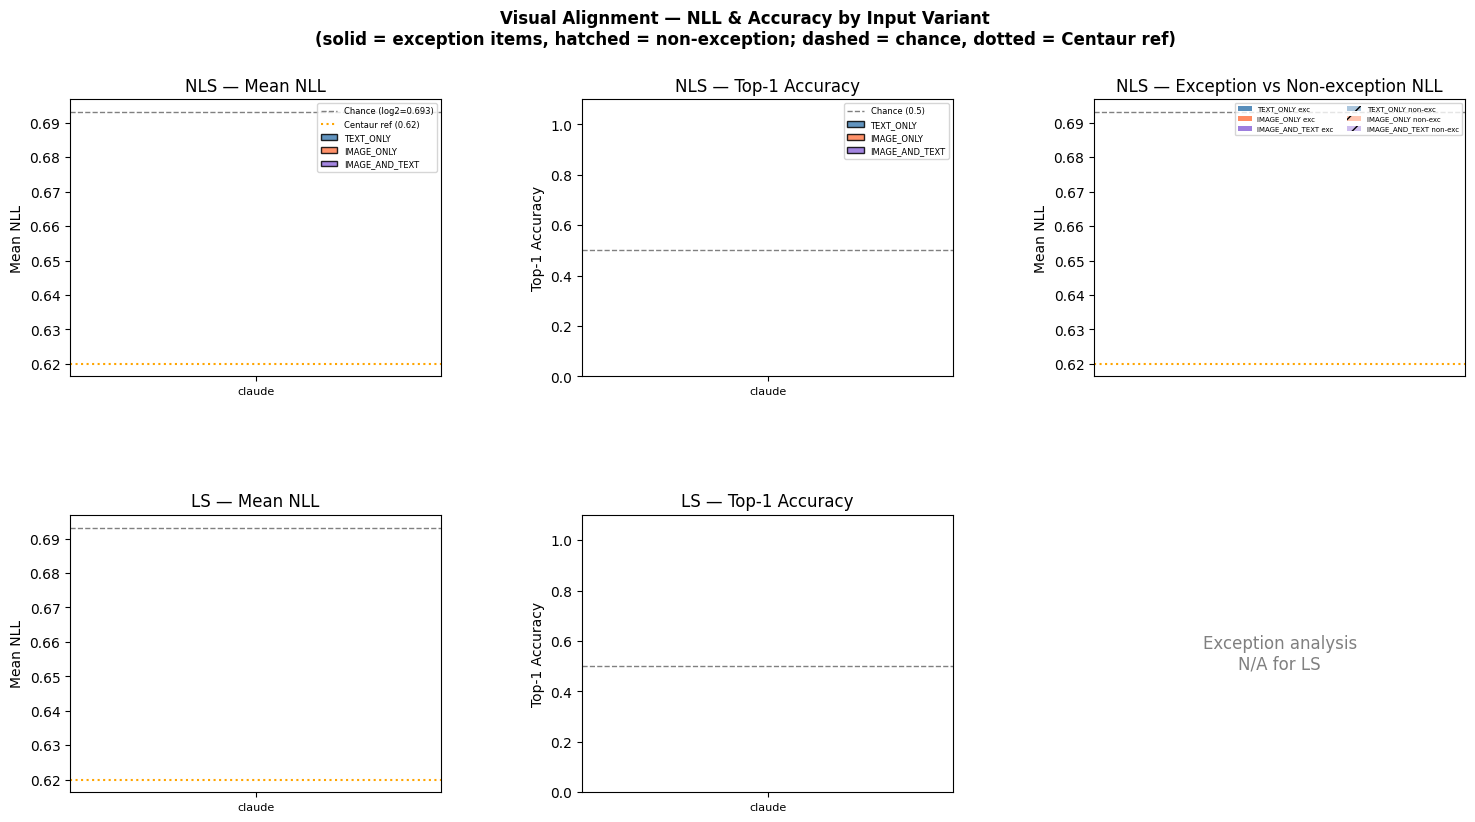

In [45]:
VARIANT_COLORS = {
    "TEXT_ONLY":      "steelblue",
    "IMAGE_ONLY":     "coral",
    "IMAGE_AND_TEXT": "mediumpurple",
}
RANDOM_NLL = np.log(2)   # ~0.693
CENTAUR_NLL = 0.62

cond_names = list(CONDITION_MAP.values())  # ["NLS", "LS"]
n_models   = len(VLM_MODELS)
n_variants = len(INPUT_VARIANTS)
bar_w      = 0.22

fig = plt.figure(figsize=(18, 9))
gs  = gridspec.GridSpec(2, 3, hspace=0.5, wspace=0.38)

for row, cond_name in enumerate(cond_names):
    # --- Col 0: Mean NLL ---
    ax = fig.add_subplot(gs[row, 0])
    x_base = np.arange(n_models)
    for vi, variant in enumerate(INPUT_VARIANTS):
        vals = [metrics[cond_name][m][variant]["mean_nll"] for m in VLM_MODELS]
        ses  = [metrics[cond_name][m][variant]["se_nll"]   for m in VLM_MODELS]
        offset = (vi - (n_variants - 1) / 2) * bar_w
        bars = ax.bar(x_base + offset, vals, bar_w,
                      color=VARIANT_COLORS[variant], alpha=0.85,
                      edgecolor="black", label=variant)
        for bar, v, se in zip(bars, vals, ses):
            if not np.isnan(v):
                ax.errorbar(bar.get_x() + bar.get_width()/2, v, yerr=se,
                            fmt="none", color="black", capsize=3, linewidth=1)
    ax.axhline(RANDOM_NLL,  color="gray",   linestyle="--", linewidth=1,
               label=f"Chance (log2={RANDOM_NLL:.3f})")
    ax.axhline(CENTAUR_NLL, color="orange",  linestyle=":",  linewidth=1.5,
               label=f"Centaur ref ({CENTAUR_NLL})")
    ax.set_xticks(x_base)
    ax.set_xticklabels([m.split("-")[0] for m in VLM_MODELS], fontsize=8)
    ax.set_ylabel("Mean NLL"); ax.set_title(f"{cond_name} — Mean NLL")
    if row == 0:
        ax.legend(fontsize=6, loc="upper right")

    # --- Col 1: Top-1 Accuracy ---
    ax = fig.add_subplot(gs[row, 1])
    for vi, variant in enumerate(INPUT_VARIANTS):
        vals = [metrics[cond_name][m][variant]["mean_acc"] for m in VLM_MODELS]
        offset = (vi - (n_variants - 1) / 2) * bar_w
        ax.bar(x_base + offset, vals, bar_w,
               color=VARIANT_COLORS[variant], alpha=0.85, edgecolor="black",
               label=variant)
    ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Chance (0.5)")
    ax.set_ylim(0, 1.1)
    ax.set_xticks(x_base)
    ax.set_xticklabels([m.split("-")[0] for m in VLM_MODELS], fontsize=8)
    ax.set_ylabel("Top-1 Accuracy"); ax.set_title(f"{cond_name} — Top-1 Accuracy")
    if row == 0:
        ax.legend(fontsize=6)

    # --- Col 2: Exception analysis (NLS only) ---
    ax = fig.add_subplot(gs[row, 2])
    if cond_name == "NLS":
        exc_bar_w = 0.18
        # Group by model, within each model show 3 variants x 2 (exc/non-exc) pairs
        for mi, model in enumerate(VLM_MODELS):
            for vi, variant in enumerate(INPUT_VARIANTS):
                exc_nll = metrics[cond_name][model][variant]["exception"]["mean_nll"]
                non_nll = metrics[cond_name][model][variant]["non_exception"]["mean_nll"]
                base_x = mi * (n_variants * 2 + 1) * exc_bar_w + vi * 2 * exc_bar_w
                ax.bar(base_x,              exc_nll, exc_bar_w,
                       color=VARIANT_COLORS[variant], alpha=0.9,  edgecolor="black")
                ax.bar(base_x + exc_bar_w,  non_nll, exc_bar_w,
                       color=VARIANT_COLORS[variant], alpha=0.45, edgecolor="black",
                       hatch="//")
        # Build legend proxies
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=VARIANT_COLORS[v], alpha=0.9,  label=f"{v} exc")
                   for v in INPUT_VARIANTS]
        handles += [Patch(facecolor=VARIANT_COLORS[v], alpha=0.45, hatch="//",
                          label=f"{v} non-exc") for v in INPUT_VARIANTS]
        ax.legend(handles=handles, fontsize=5, loc="upper right", ncol=2)
        ax.axhline(RANDOM_NLL,  color="gray",  linestyle="--", linewidth=1)
        ax.axhline(CENTAUR_NLL, color="orange", linestyle=":",  linewidth=1.5)
        ax.set_ylabel("Mean NLL")
        ax.set_title("NLS — Exception vs Non-exception NLL")
        ax.set_xticks([])
    else:
        ax.axis("off")
        ax.text(0.5, 0.5, "Exception analysis\nN/A for LS",
                ha="center", va="center", fontsize=12,
                transform=ax.transAxes, color="gray")

plt.suptitle(
    "Visual Alignment — NLL & Accuracy by Input Variant\n"
    "(solid = exception items, hatched = non-exception; dashed = chance, dotted = Centaur ref)",
    fontsize=12, fontweight="bold")
plt.savefig("visual_alignment_fig1_grid.png", dpi=150, bbox_inches="tight")
plt.show()


### Figure 2 — Modality Effect on Behavioral Alignment (NLS Condition)

Key poster figure: side-by-side NLL bars for `text_only` vs `image_only` vs `image_and_text`, NLS condition only, per model.

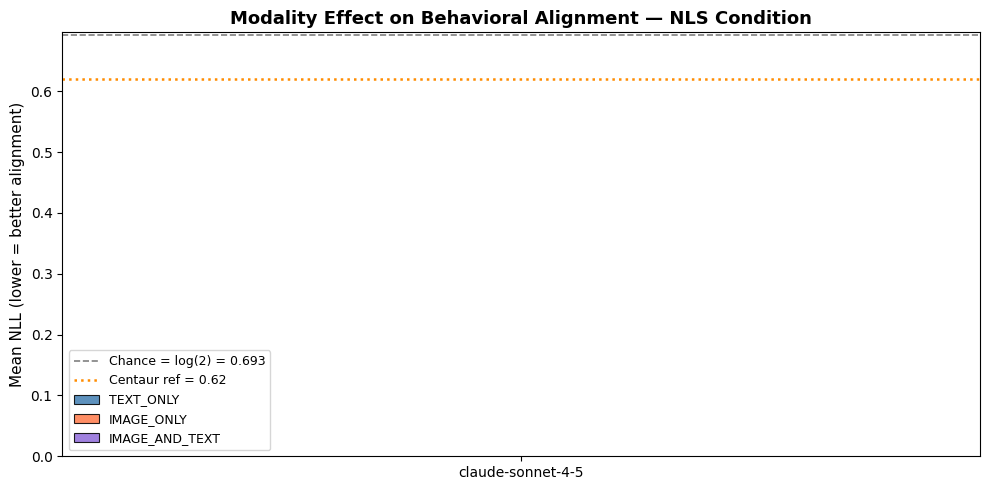

In [46]:
cond_name = "NLS"
bar_w2 = 0.22

fig, ax = plt.subplots(figsize=(10, 5))

x_base = np.arange(n_models)
for vi, variant in enumerate(INPUT_VARIANTS):
    vals = [metrics[cond_name][m][variant]["mean_nll"] for m in VLM_MODELS]
    ses  = [metrics[cond_name][m][variant]["se_nll"]   for m in VLM_MODELS]
    offset = (vi - (n_variants - 1) / 2) * bar_w2
    bars = ax.bar(x_base + offset, vals, bar_w2,
                  color=VARIANT_COLORS[variant], alpha=0.88,
                  edgecolor="black", linewidth=0.8, label=variant)
    for bar, v, se in zip(bars, vals, ses):
        if not np.isnan(v):
            ax.errorbar(bar.get_x() + bar.get_width()/2, v, yerr=se,
                        fmt="none", color="black", capsize=3, linewidth=1)
            ax.text(bar.get_x() + bar.get_width()/2,
                    v + (se if not np.isnan(se) else 0) + 0.01,
                    f"{v:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.axhline(RANDOM_NLL,  color="gray",  linestyle="--", linewidth=1.2,
           label=f"Chance = log(2) = {RANDOM_NLL:.3f}")
ax.axhline(CENTAUR_NLL, color="darkorange", linestyle=":", linewidth=1.8,
           label=f"Centaur ref = {CENTAUR_NLL}")

ax.set_xticks(x_base)
ax.set_xticklabels([m for m in VLM_MODELS], fontsize=10)
ax.set_ylabel("Mean NLL (lower = better alignment)", fontsize=11)
ax.set_ylim(bottom=0)
ax.legend(fontsize=9)

plt.title(
    "Modality Effect on Behavioral Alignment — NLS Condition",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.savefig("visual_alignment_fig2_modality_nls.png", dpi=150, bbox_inches="tight")
plt.show()
